# CNN Basics — Convolutional Neural Networks

## Goal
Understand how CNNs detect patterns using filters.
CNNs revolutionized computer vision — and the same ideas appear in NLP.

## Key Questions
- What is a convolution and what does it detect?
- How do filters learn to recognize patterns?
- What is pooling and why does it matter?

## What We Build
A CNN from scratch using numpy — implementing convolution and pooling manually.
Then we use PyTorch to train a simple CNN on real data.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import image as mpimg
import matplotlib.cbook as cbook
import torch
import torch.nn as nn
import torch.optim as optim

## 1. What is Convolution?
A filter slides over the input and detects patterns.
Different filters detect different features — edges, curves, textures.

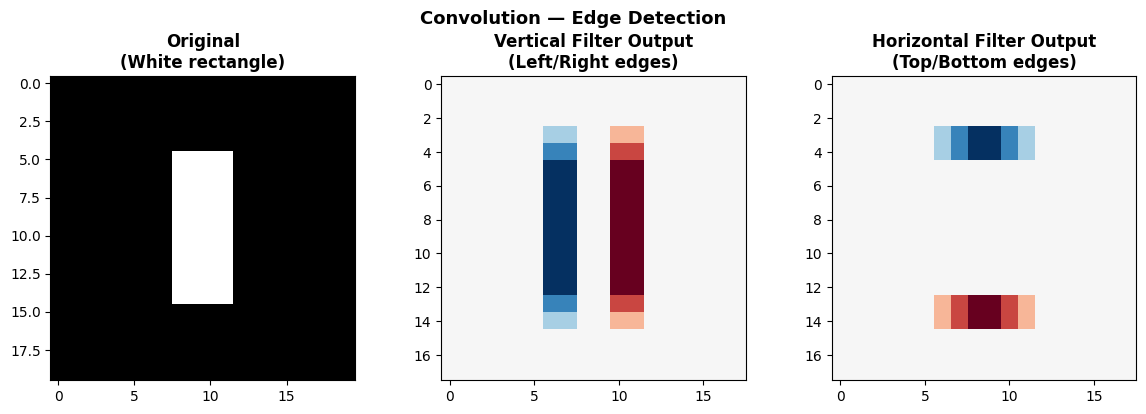

In [12]:
def convolve2d(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """Apply a convolution filter to an image."""
    h, w = image.shape
    kh, kw = kernel.shape
    output_h = h - kh + 1
    output_w = w - kw + 1
    output = np.zeros((output_h, output_w))
    for i in range(output_h):
        for j in range(output_w):
            output[i, j] = np.sum(image[i:i+kh, j:j+kw] * kernel)
    return output

image = np.zeros((20, 20))
image[5:15, 8:12] = 1.0

vertical_filter = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
horizontal_filter = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])

vertical_output = convolve2d(image, vertical_filter)
horizontal_output = convolve2d(image, horizontal_filter)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(image, cmap="gray", interpolation="nearest")
axes[0].set_title("Original\n(White rectangle)", fontweight="bold")

axes[1].imshow(vertical_output, cmap="RdBu", interpolation="nearest")
axes[1].set_title("Vertical Filter Output\n(Left/Right edges)", fontweight="bold")

axes[2].imshow(horizontal_output, cmap="RdBu", interpolation="nearest")
axes[2].set_title('Horizontal Filter Output\n(Top/Bottom edges)', fontweight="bold")

plt.suptitle("Convolution — Edge Detection", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("convolution.png", dpi=300)
plt.show()

## 2. Pooling — Reducing Spatial Size
Pooling reduces the size of feature maps while keeping important information.
Max pooling takes the maximum value in each region.

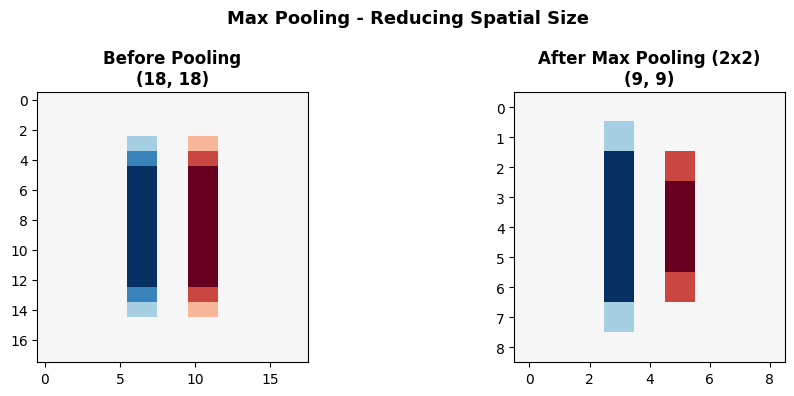

Before pooling: (18, 18)
After pooling: (9, 9)
Size reduced by: 4x


In [17]:
def max_pool2d(feature_map: np.ndarray, pool_size: int = 2) -> np.ndarray:
    """
    Max pooling - takes the maximum value in each pool_size x pool_size region.
    Reduces spatial dimensions by pool_size factor.
    """
    h, w = feature_map.shape
    out_h = h // pool_size
    out_w = w // pool_size
    output = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            region = feature_map[i*pool_size:(i+1)*pool_size,
                j*pool_size:(j+1)*pool_size]
            output[i, j] = np.max(region)

    return output

# Apply pooling to vertical output
pooled = max_pool2d(vertical_output, pool_size=2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(vertical_output, cmap="RdBu", interpolation="nearest")
axes[0].set_title(f"Before Pooling\n{vertical_output.shape}", fontweight="bold")

axes[1].imshow(pooled, cmap="RdBu", interpolation="nearest")
axes[1].set_title(f"After Max Pooling (2x2)\n{pooled.shape}", fontweight="bold")

plt.suptitle("Max Pooling - Reducing Spatial Size", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("pooling.png", dpi=300)
plt.show()

print(f"Before pooling: {vertical_output.shape}")
print(f"After pooling: {pooled.shape}")
print(f"Size reduced by: {vertical_output.size // pooled.size}x")

## 3. Key Observations

## What Convolution Does
- A filter slides over the input and computes dot products
- Each filter detects a specific pattern — edge, curve, texture
- Different filters detect different features simultaneously
- Output size: (input_size - filter_size + 1)

## What Pooling Does
- Reduces spatial dimensions while keeping important features
- Max pooling: takes the strongest activation in each region
- Makes the network invariant to small translations
- Reduces computation in deeper layers

## Why CNNs Work for Images
- Filters are shared across the entire image (parameter efficiency)
- Hierarchical features: edges -> shapes -> objects
- Same filter detects a vertical edge anywhere in the image

## Connection to NLP
- 1D convolution over text: filter slides over word sequences
- Detects n-gram patterns — similar to how TF-IDF captures bigrams
- Used in text classification before transformers

## Next
How do networks handle sequences?
-> 05_rnn_basics.ipynb